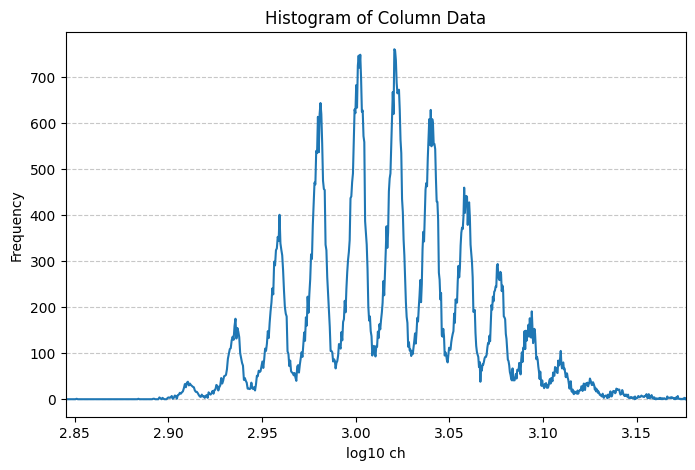

In [35]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# 1. txtファイルの読み込み（スペース区切りの場合: sep=r'\s+'、カンマ区切りの場合: sep=','）
# header=None はファイルに列名（ヘッダー）が含まれていない場合に設定します
df = pd.read_csv("summer025_ADC_HIGH_7.txt", sep=r'\s+', header=None)
channels = df[0]
counts = df[1]

logch = np.log10(channels)

plt.figure(figsize=(8, 5))
plt.plot(logch,df[1])
plt.xlim(np.log10(700),np.log10(1500))
# グラフの装飾

plt.title("Histogram of Column Data")
plt.xlabel("log10 ch")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 表示
plt.show()



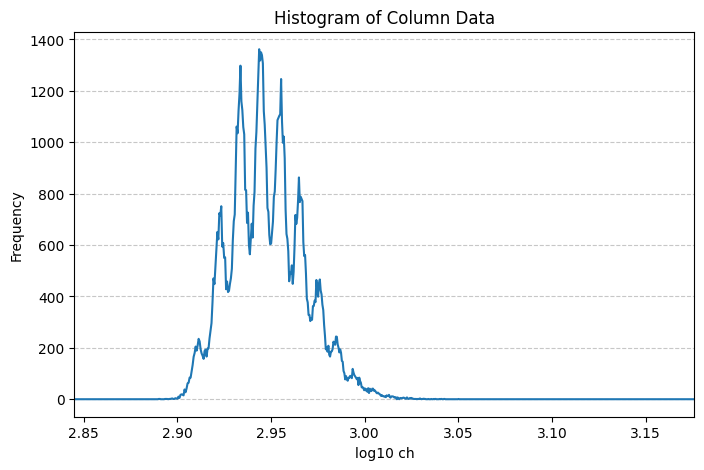

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
# 1. txtファイルの読み込み（スペース区切りの場合: sep=r'\s+'、カンマ区切りの場合: sep=','）
# header=None はファイルに列名（ヘッダー）が含まれていない場合に設定します
df = pd.read_csv("summer017_ADC_HIGH_7.txt", sep=r'\s+', header=None)
channels = df[0]
counts = df[1]

logch = np.log10(channels)

plt.figure(figsize=(8, 5))
plt.plot(logch,df[1])
plt.xlim(np.log10(700),np.log10(1500))
# グラフの装飾

plt.title("Histogram of Column Data")
plt.xlabel("log10 ch")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# 表示
plt.show()



    data_num   max_x  log10_max_x   max_y
0         11   814.5     2.910891  7158.0
1         12   818.5     2.913019  5653.0
2         13   826.5     2.917243  3423.0
3         14   838.5     2.923503  2316.0
4         15   846.5     2.927627  1894.0
5         16   870.5     2.939769  1589.0
6         17   878.5     2.943742  1362.0
7         18   890.5     2.949634  1331.0
8         19   898.5     2.953518  1159.0
9         20   938.5     2.972434  1097.0
10        21   954.5     2.979776  1056.0
11        22   965.5     2.984752   976.0
12        23   978.5     2.990561   919.0
13        24   990.5     2.995854   806.0
14        25  1048.5     3.020568   761.0


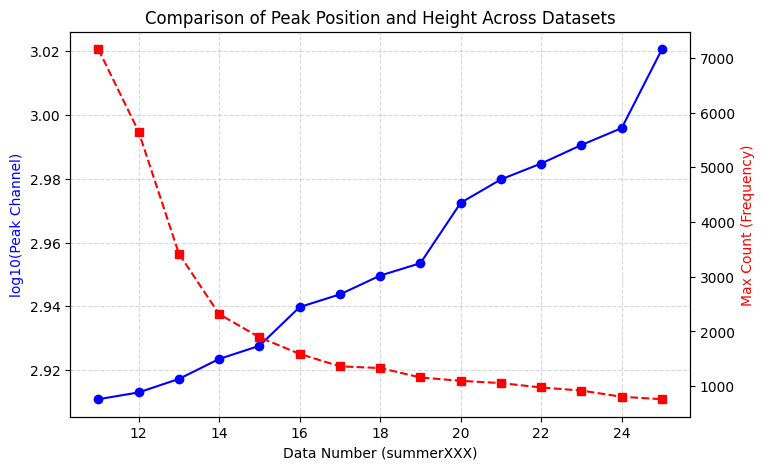

In [40]:
import glob
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 該当するtxtファイルをすべて検索してソート
file_list = sorted(glob.glob("summer*_ADC_HIGH_7.txt"))

results = []

for filepath in file_list:
    # ファイル名からデータ番号（例: summer011 -> 11）を抽出
    match = re.search(r"summer(\d+)", filepath)
    data_num = int(match.group(1)) if match else filepath

    # データ読み込み
    df = pd.read_csv(filepath, sep=r"\s+", header=None)

    # y (カウント数: 列1) が最大となる行のインデックスを取得
    max_idx = df[1].idxmax()
    max_y = df[1].iloc[max_idx]
    max_x = df[0].iloc[max_idx]
    log10_max_x = np.log10(max_x)

    results.append(
        {
            "data_num": data_num,
            "max_x": max_x,
            "log10_max_x": log10_max_x,
            "max_y": max_y,
            "file": filepath,
        }
    )

# 結果をDataFrameにまとめる
res_df = pd.DataFrame(results)
print(res_df[["data_num", "max_x", "log10_max_x", "max_y"]])

# --- 比較プロット ---
fig, ax1 = plt.subplots(figsize=(8, 5))

# データ番号 vs ピーク位置 log10(x)
ax1.plot(
    res_df["data_num"], res_df["log10_max_x"], "o-b", label="log10(Peak x)"
)
ax1.set_xlabel("Data Number (summerXXX)")
ax1.set_ylabel("log10(Peak Channel)", color="b")
ax1.grid(True, linestyle="--", alpha=0.5)

# データ番号 vs ピークの高さ (y最大値) を右軸に表示
ax2 = ax1.twinx()
ax2.plot(res_df["data_num"], res_df["max_y"], "s--r", label="Max Count")
ax2.set_ylabel("Max Count (Frequency)", color="r")

plt.title("Comparison of Peak Position and Height Across Datasets")
plt.show()

In [ ]:
直線だと信じれば
x' = exp(b) * x ^ a
log x' = a log x + b